<a href="https://colab.research.google.com/github/hema357/customer-shopping-behavior-eda/blob/main/shopping_behavior_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Setup environments
!pip install pandas matplotlib seaborn numpy

In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Configure plotting style
sns.set_theme(style='whitegrid')

In [ ]:
# Checked all core libraries loaded successfully

In [ ]:
import os

# Using the extract_path defined in your working data loading cell
if 'extract_path' in locals():
    for root, dirs, files in os.walk(extract_path):
        for file in files:
            print(os.path.join(root, file))
else:
    print("Extract path not found. Please ensure the data extraction cell has been run.")

/content/extracted_data/shopping_behavior_updated.csv


In [ ]:
import os
import zipfile
import pandas as pd

# Define paths for the archive and extraction
archive_path = '/content/archive (1).zip'
extract_path = '/content/extracted_data'

# Ensure the extraction directory exists
os.makedirs(extract_path, exist_ok=True)

# Extract data if the archive exists
if os.path.exists(archive_path):
    with zipfile.ZipFile(archive_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    data_file = os.path.join(extract_path, 'shopping_behavior_updated.csv')
else:
    # Fallback if already extracted or in another location
    # This assumes the file might be directly in /content or elsewhere if not zipped.
    # For this specific notebook context, we'll assume it's in the extract_path if archive isn't found.
    data_file = os.path.join(extract_path, 'shopping_behavior_updated.csv')

# Load the dataset
if os.path.exists(data_file):
    df = pd.read_csv(data_file)
    print("Dataset loaded successfully!")
    display(df.head())
else:
    print(f"Error: {data_file} not found. Please ensure the file is in the current directory or extracted.")

Dataset loaded successfully!


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


# 1. Understanding the Data Structure

In [ ]:
# Display the first 5 rows of the dataset
print("\nFirst 5 rows of the dataset:")
print(df.head())


First 5 rows of the dataset:
   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   Shipping Type Discount 

In [ ]:
# Display the shape of the dataset (number of rows, number of columns)
print(f"\nShape of the dataset (rows, columns): {df.shape}")


Shape of the dataset (rows, columns): (3900, 18)


In [ ]:
# Get a concise summary of the DataFrame, including data types and non-null values
print("\nConcise summary of the DataFrame (df.info()):")
df.info()


Concise summary of the DataFrame (df.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object

In [ ]:
# Get the names of all columns
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']


In [ ]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
print("\nNumerical columns:")
print(numerical_cols)


Numerical columns:
['Customer ID', 'Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']


In [ ]:
# Identify Categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("\nCategorical columns:")
print(categorical_cols)


Categorical columns:
['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color', 'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Payment Method', 'Frequency of Purchases']


In [ ]:
print("Numerical Cols: ", numerical_cols)
print("Categorical Cols: ", categorical_cols)

Numerical Cols:  ['Customer ID', 'Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
Categorical Cols:  ['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color', 'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Payment Method', 'Frequency of Purchases']


# 2. Summary Statistics

In [ ]:
# Descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
print(df[numerical_cols].describe())


Descriptive statistics for numerical columns:
       Customer ID          Age  Purchase Amount (USD)  Review Rating  \
count  3900.000000  3900.000000            3900.000000    3900.000000   
mean   1950.500000    44.068462              59.764359       3.749949   
std    1125.977353    15.207589              23.685392       0.716223   
min       1.000000    18.000000              20.000000       2.500000   
25%     975.750000    31.000000              39.000000       3.100000   
50%    1950.500000    44.000000              60.000000       3.700000   
75%    2925.250000    57.000000              81.000000       4.400000   
max    3900.000000    70.000000             100.000000       5.000000   

       Previous Purchases  
count         3900.000000  
mean            25.351538  
std             14.447125  
min              1.000000  
25%             13.000000  
50%             25.000000  
75%             38.000000  
max             50.000000  


In [ ]:
# Value counts for categorical columns
print("\nValue counts for categorical columns (top 10 for brevity):")
for col in categorical_cols:
    print(f"\n--- Column: {col} ---")
# Displaying top 10 for columns with many unique values
    print(df[col].value_counts().head(10))



# VALUE_COUNT


Value counts for categorical columns (top 10 for brevity):

--- Column: Gender ---
Gender
Male      2652
Female    1248
Name: count, dtype: int64

--- Column: Item Purchased ---
Item Purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Name: count, dtype: int64

--- Column: Category ---
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

--- Column: Location ---
Location
Montana       96
California    95
Idaho         93
Illinois      92
Alabama       89
Minnesota     88
New York      87
Nevada        87
Nebraska      87
Delaware      86
Name: count, dtype: int64

--- Column: Size ---
Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64

--- Column: Color ---
Color
Olive     177
Yellow    174
Silver    173
Teal      172
Green     169
Black     167
Cyan      166
Viol

# 3. Missing Values Analysis

In [ ]:
# Check for missing values
print("\nMissing values per column:")
missing_values = df.isnull().sum()
print(missing_values)


Missing values per column:
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64


In [ ]:
# Calculate percentage of missing values
print("\nPercentage of missing values per column:")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)


Percentage of missing values per column:
Customer ID               0.0
Age                       0.0
Gender                    0.0
Item Purchased            0.0
Category                  0.0
Purchase Amount (USD)     0.0
Location                  0.0
Size                      0.0
Color                     0.0
Season                    0.0
Review Rating             0.0
Subscription Status       0.0
Shipping Type             0.0
Discount Applied          0.0
Promo Code Used           0.0
Previous Purchases        0.0
Payment Method            0.0
Frequency of Purchases    0.0
dtype: float64


In [ ]:
# Dataset is clean. No missing values found, so no imputation is needed.

# 4. Outlier Detection


--- Step 4: Outlier Detection (using Box Plots) ---


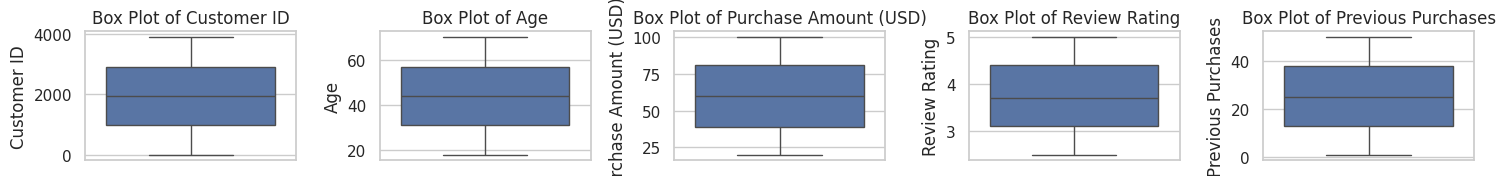

In [ ]:
print("\n--- Step 4: Outlier Detection (using Box Plots) ---")

plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols):
    plt.subplot(5, 5, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style
sns.set(style='whitegrid')

# A. AGE

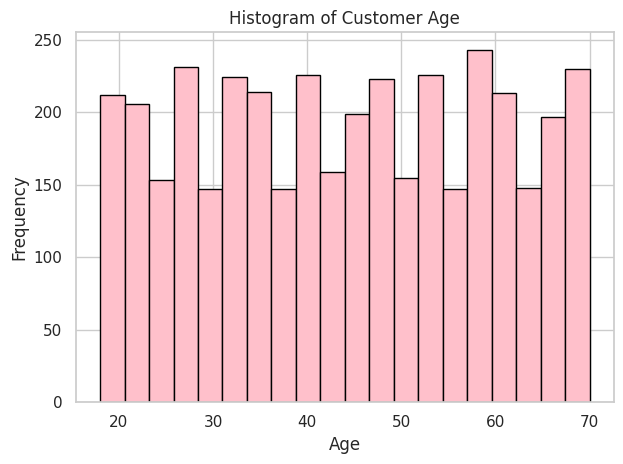

In [ ]:
plt.figure()
plt.hist(df['Age'], bins=20, color='pink', edgecolor='black')
plt.title('Histogram of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


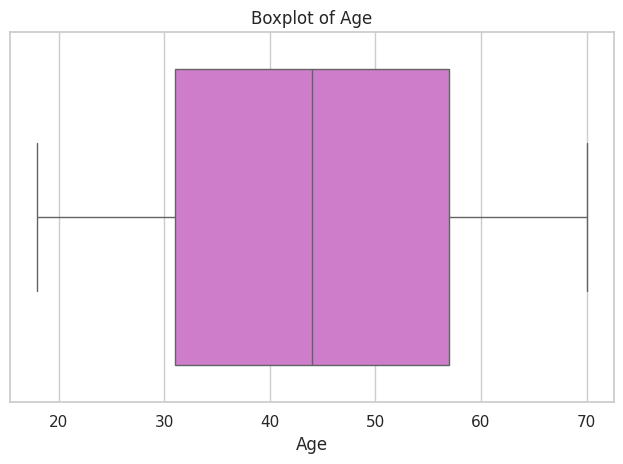

In [ ]:
plt.figure()
sns.boxplot(x=df['Age'], color='orchid')
plt.title('Boxplot of Age')
plt.tight_layout()
plt.show()

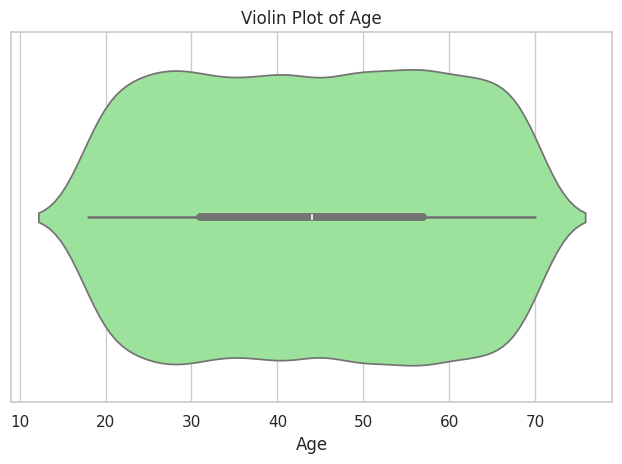

In [ ]:
plt.figure()
sns.violinplot(x=df['Age'], color='lightgreen')
plt.title('Violin Plot of Age')
plt.tight_layout()
plt.show()

/tmp/ipykernel_830/1695966945.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Age'], shade=True, color='navy')


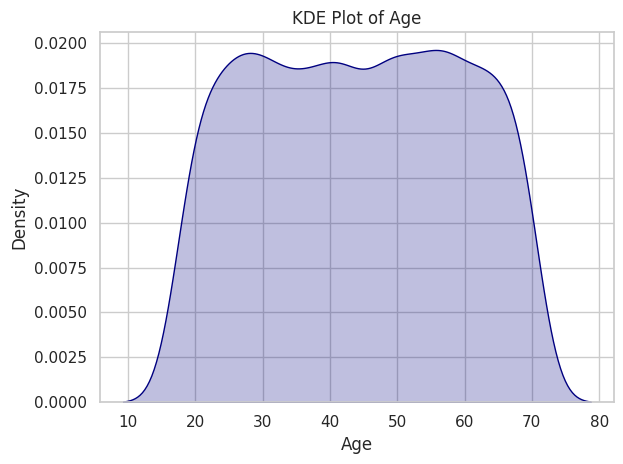

In [ ]:
plt.figure()
sns.kdeplot(df['Age'], shade=True, color='navy')
plt.title('KDE Plot of Age')
plt.xlabel('Age')
plt.tight_layout()
plt.show()

# B. Purchase Amount (USD)

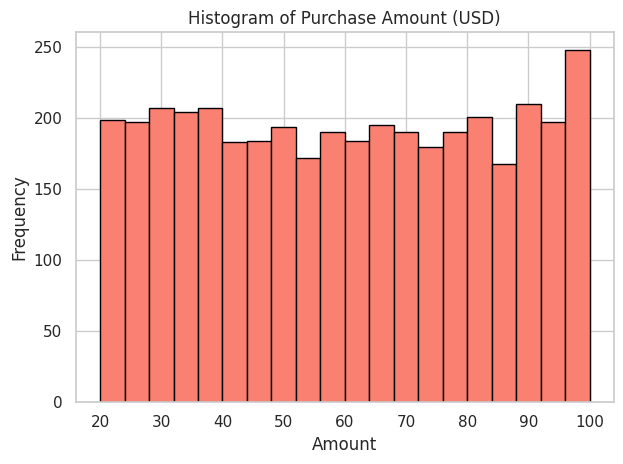

In [ ]:
plt.figure()
plt.hist(df['Purchase Amount (USD)'], bins=20, color='salmon', edgecolor='black')
plt.title('Histogram of Purchase Amount (USD)')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

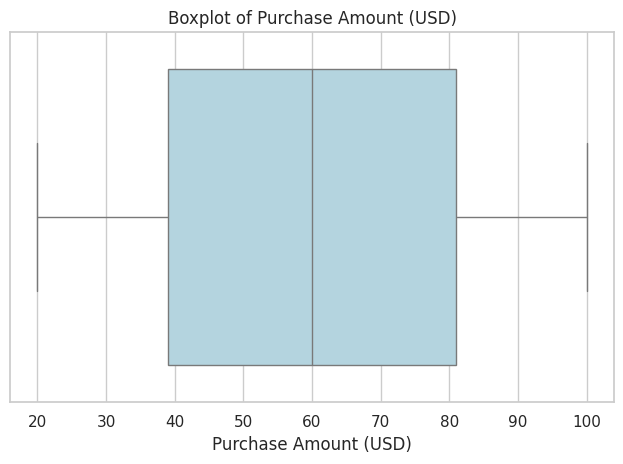

In [ ]:
plt.figure()
sns.boxplot(x=df['Purchase Amount (USD)'], color='lightblue')
plt.title('Boxplot of Purchase Amount (USD)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_830/2623860844.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Purchase Amount (USD)'], shade=True, color='purple')


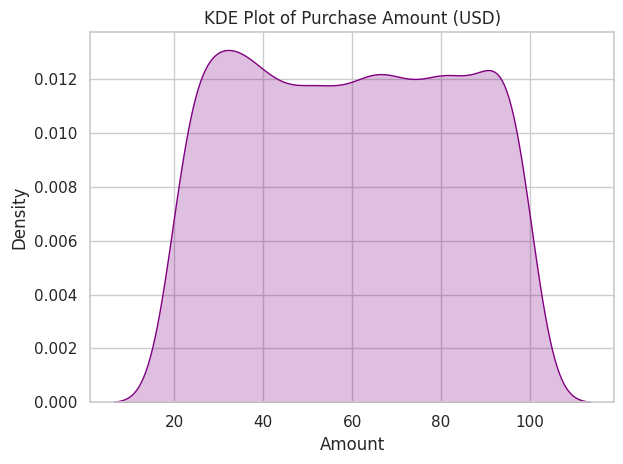

In [ ]:
plt.figure()
sns.kdeplot(df['Purchase Amount (USD)'], shade=True, color='purple')
plt.title('KDE Plot of Purchase Amount (USD)')
plt.xlabel('Amount')
plt.tight_layout()
plt.show()

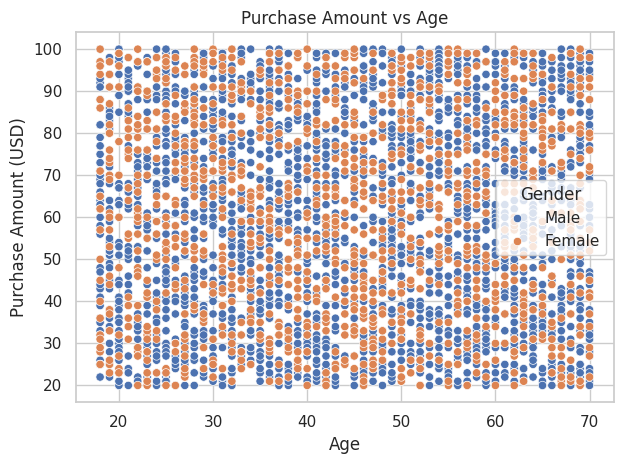

In [ ]:
plt.figure()
sns.scatterplot(x='Age', y='Purchase Amount (USD)', data=df, hue='Gender')
plt.title('Purchase Amount vs Age')
plt.tight_layout()
plt.show()

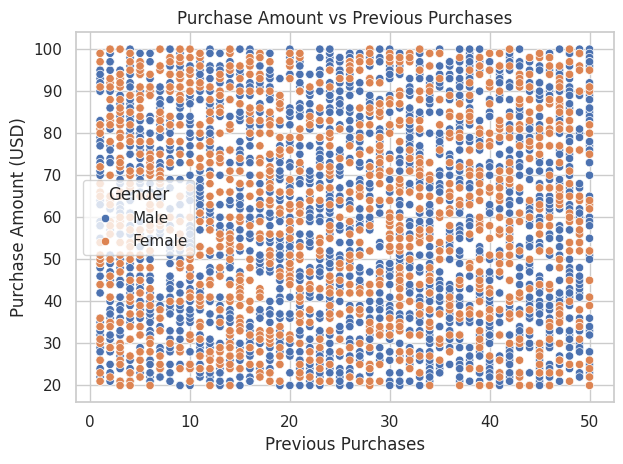

In [ ]:
plt.figure()
sns.scatterplot(x='Previous Purchases', y='Purchase Amount (USD)', data=df, hue='Gender')
plt.title('Purchase Amount vs Previous Purchases')
plt.tight_layout()
plt.show()

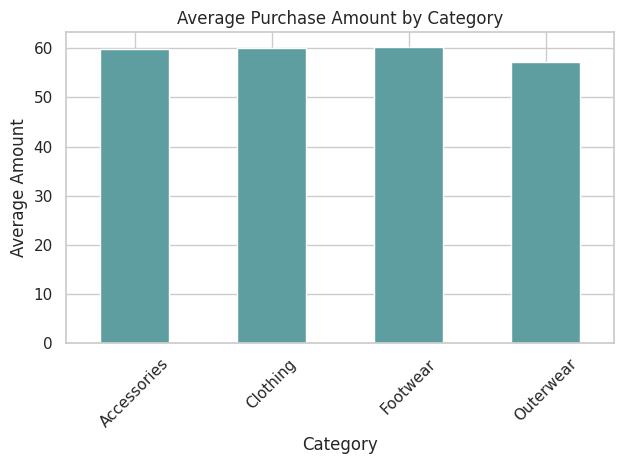

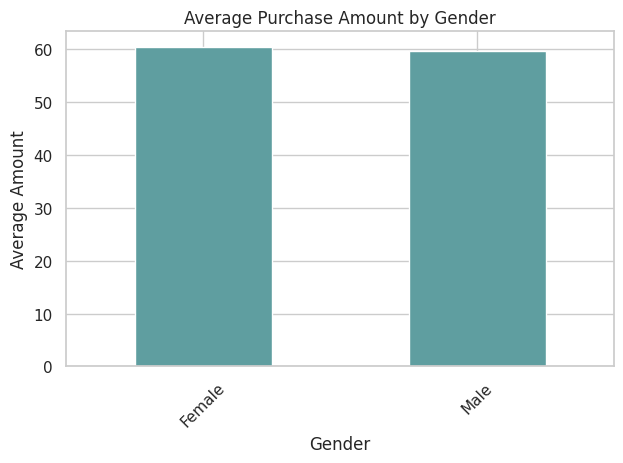

In [ ]:
for col in ['Category', 'Gender']:
    plt.figure()
    df.groupby(col)['Purchase Amount (USD)'].mean().plot(kind='bar', color='cadetblue')
    plt.title(f'Average Purchase Amount by {col}')
    plt.ylabel('Average Amount')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_830/765641873.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Review Rating', data=df, palette='magma')


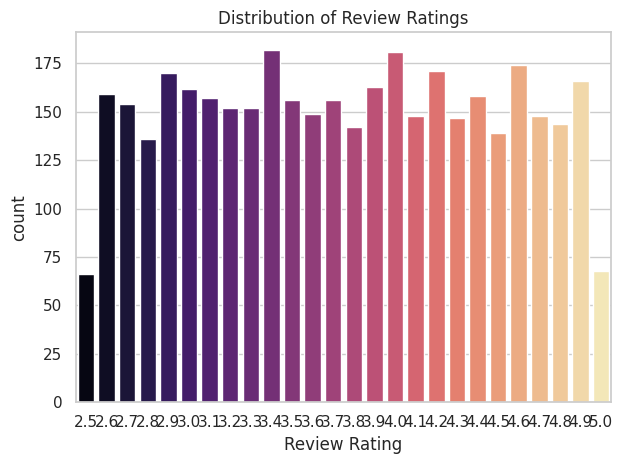

In [ ]:
# COUNTPLOT
plt.figure()
sns.countplot(x='Review Rating', data=df, palette='magma')
plt.title('Distribution of Review Ratings')
plt.tight_layout()
plt.show()

/tmp/ipykernel_830/916574361.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Review Rating', data=df, palette='coolwarm')


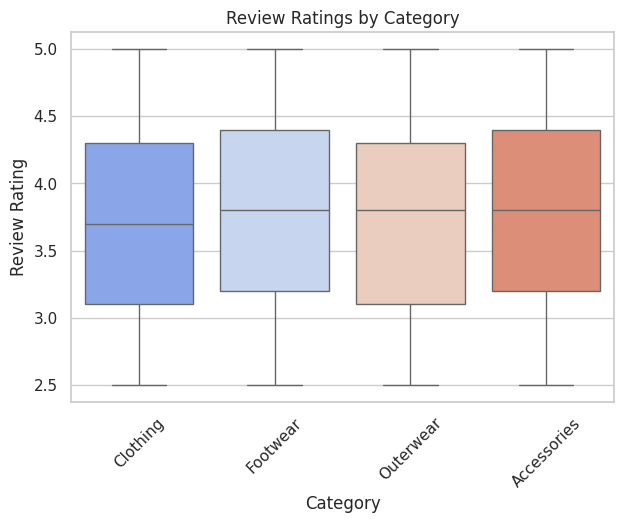

In [ ]:
# Ratings by Category
plt.figure()
sns.boxplot(x='Category', y='Review Rating', data=df, palette='coolwarm')
plt.title('Review Ratings by Category')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_830/516712237.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Item Purchased', y='Review Rating', data=df, palette='coolwarm')


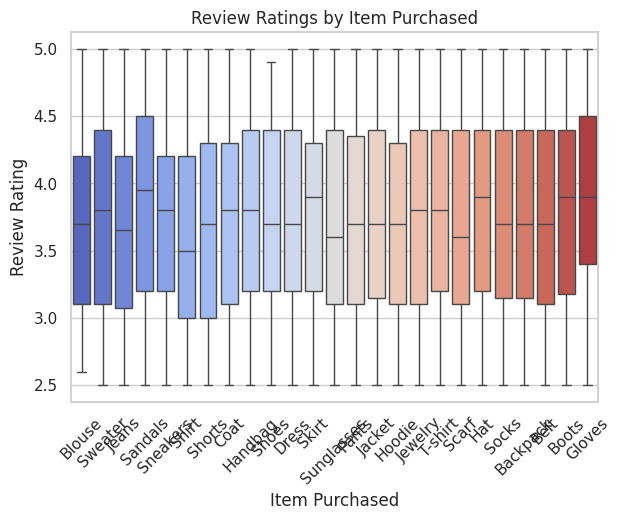

In [ ]:
# Ratings by Item Purchased
plt.figure(25)
sns.boxplot(x='Item Purchased', y='Review Rating', data=df, palette='coolwarm')
plt.title('Review Ratings by Item Purchased')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

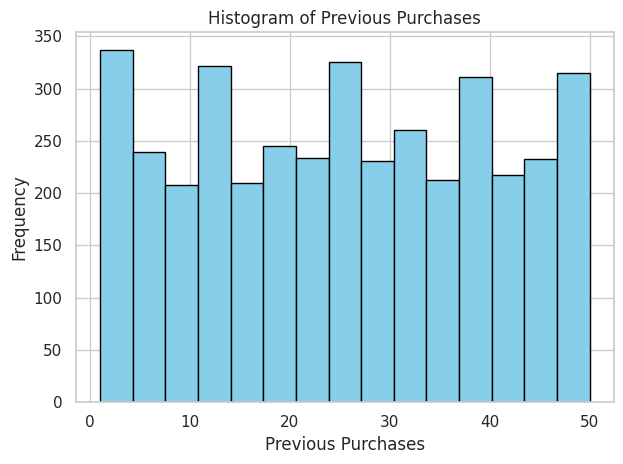

In [ ]:
plt.figure()
plt.hist(df['Previous Purchases'], bins=15, color='skyblue', edgecolor='black')
plt.title('Histogram of Previous Purchases')
plt.xlabel('Previous Purchases')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

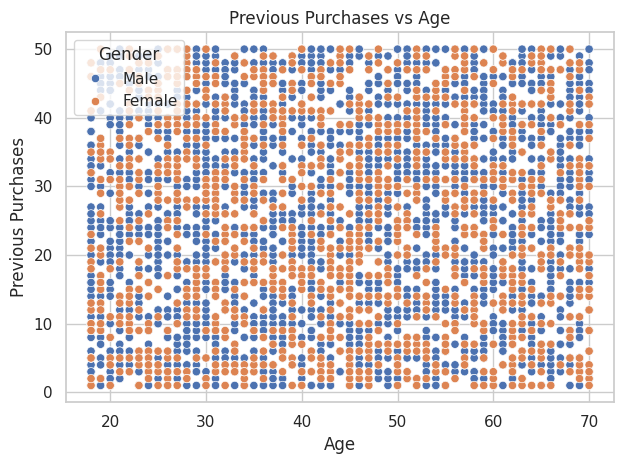

In [ ]:
plt.figure()
sns.scatterplot(x='Age', y='Previous Purchases', data=df, hue='Gender')
plt.title('Previous Purchases vs Age')
plt.tight_layout()
plt.show()

# 5. Univariate Analysis


Histograms for numerical columns:


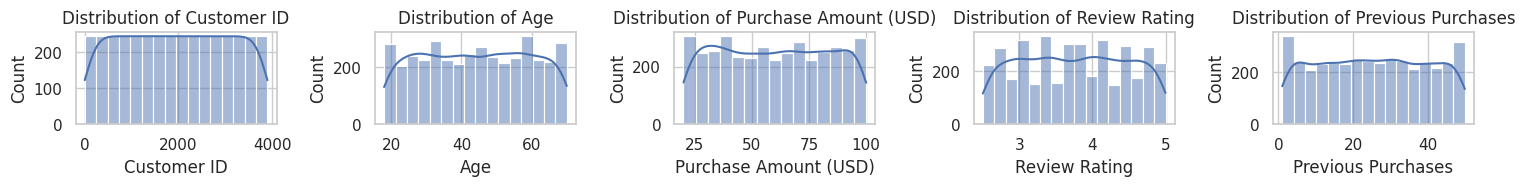

In [ ]:
# Histograms for numerical columns (Distribution)
print("\nHistograms for numerical columns:")
plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols):
    plt.subplot(5, 5, i + 1)
    sns.histplot(df[col], kde=True) # kde=True adds a smooth density curve
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


Bar plots for categorical columns:


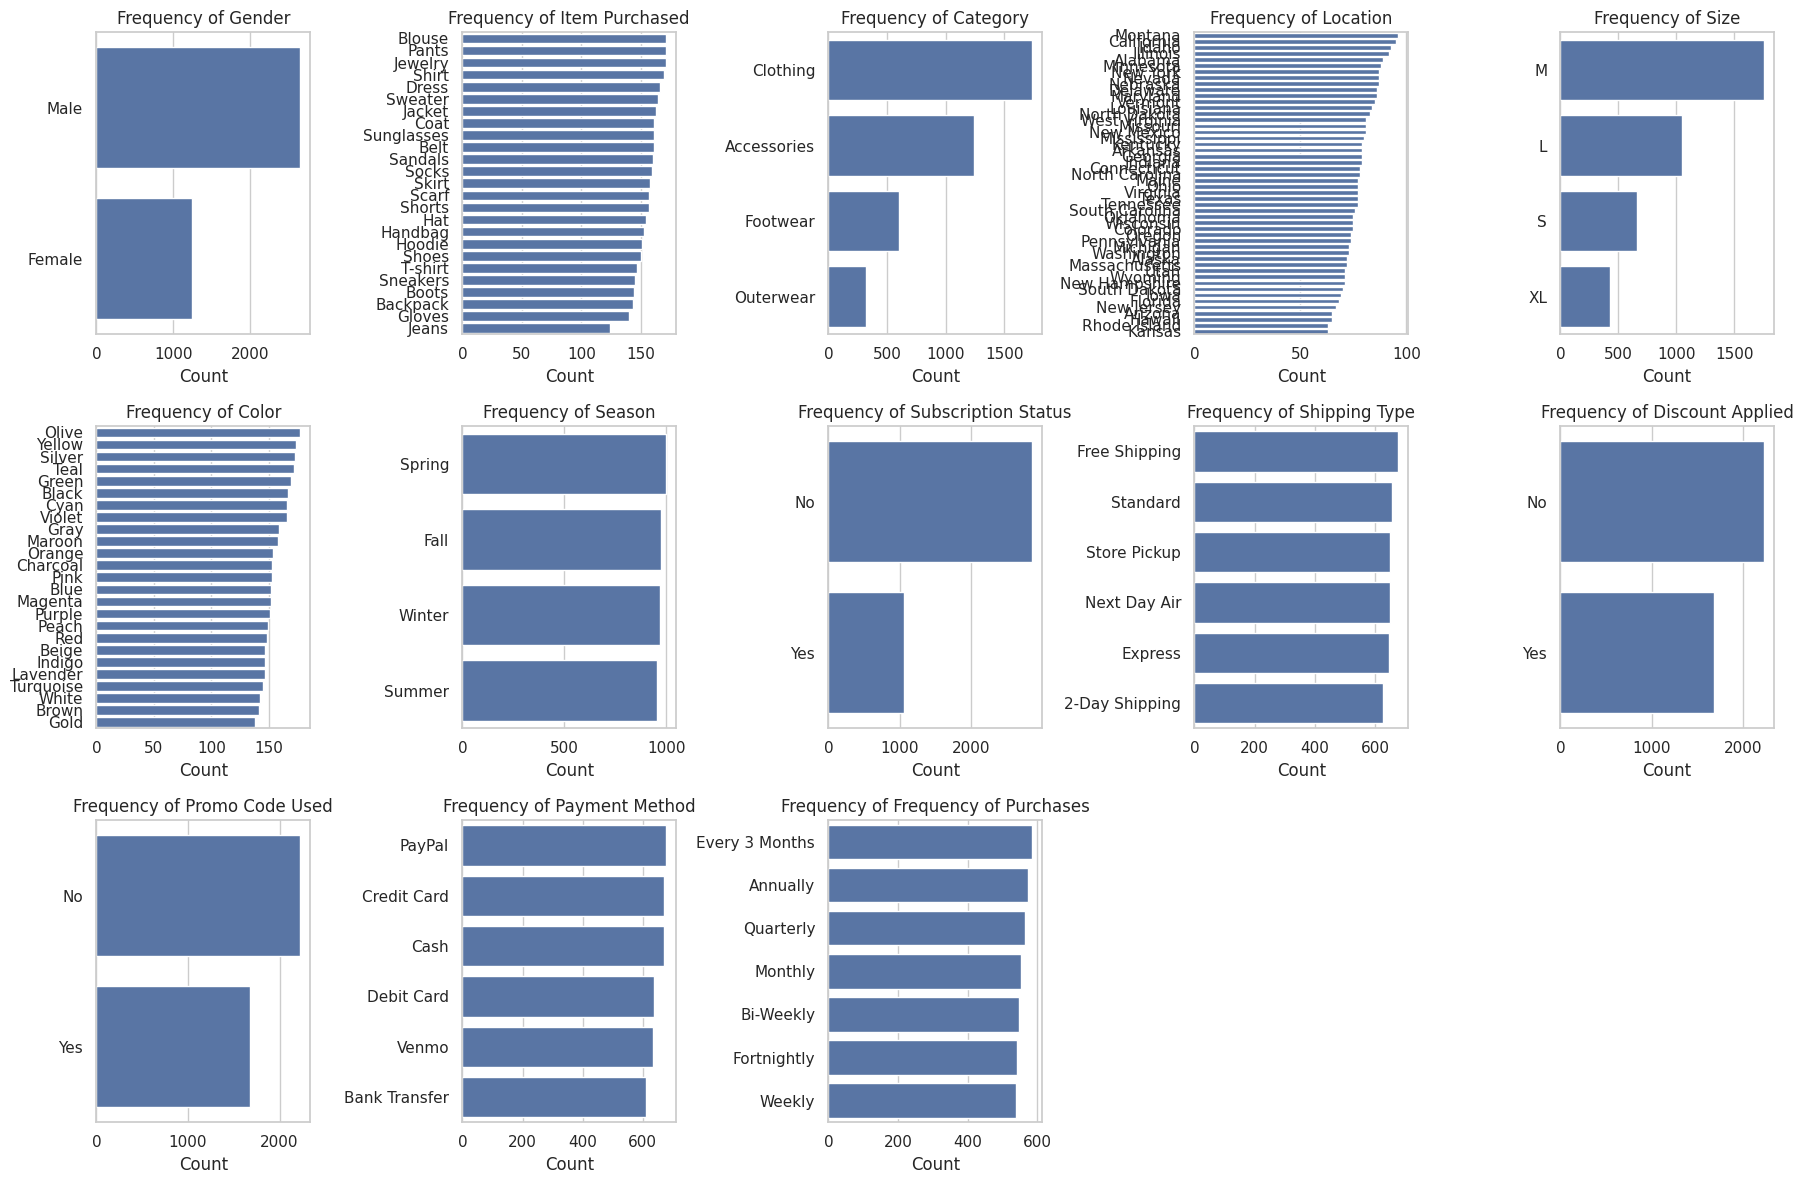

In [ ]:
# Bar plots for categorical columns (Frequency)
print("\nBar plots for categorical columns:")
plt.figure(figsize=(18, 12)) # Adjust figure size as needed
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 5, i + 1) # Adjust subplot grid (e.g., 3 rows, 5 columns)
    sns.countplot(y=df[col], order=df[col].value_counts().index) # Use y for horizontal bars if categories are many
    plt.title(f'Frequency of {col}')
    plt.xlabel('Count')
    plt.ylabel('') # Remove y-axis label to avoid clutter
plt.tight_layout()
plt.show()

# 6. Bivariate Analysis


A. Numerical vs. Numerical:

Correlation Matrix:
                       Customer ID       Age  Purchase Amount (USD)  \
Customer ID               1.000000 -0.004079               0.011048   
Age                      -0.004079  1.000000              -0.010424   
Purchase Amount (USD)     0.011048 -0.010424               1.000000   
Review Rating             0.001343 -0.021949               0.030776   
Previous Purchases       -0.039159  0.040445               0.008063   

                       Review Rating  Previous Purchases  
Customer ID                 0.001343           -0.039159  
Age                        -0.021949            0.040445  
Purchase Amount (USD)       0.030776            0.008063  
Review Rating               1.000000            0.004229  
Previous Purchases          0.004229            1.000000  


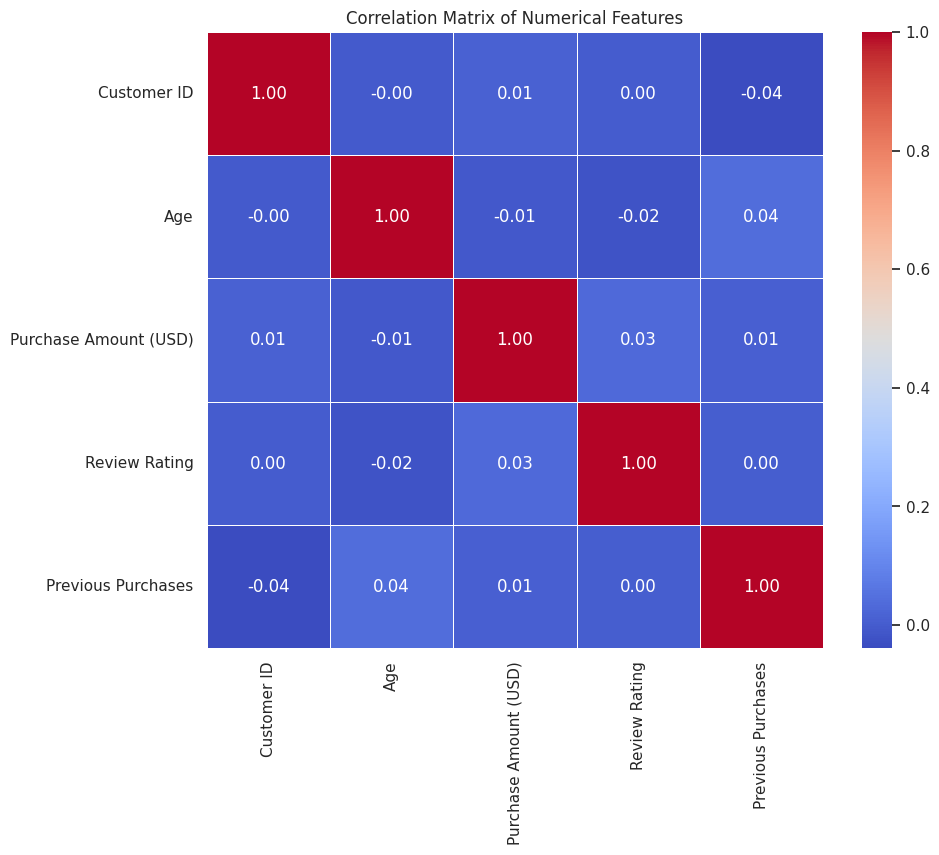

In [ ]:
# A. Numerical vs. Numerical: Scatter plots and Correlation Matrix
print("\nA. Numerical vs. Numerical:")
print("\nCorrelation Matrix:")
corr_matrix = df[numerical_cols].corr()
print(corr_matrix)

# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()


Pairplot (Scatter plots for numerical columns):


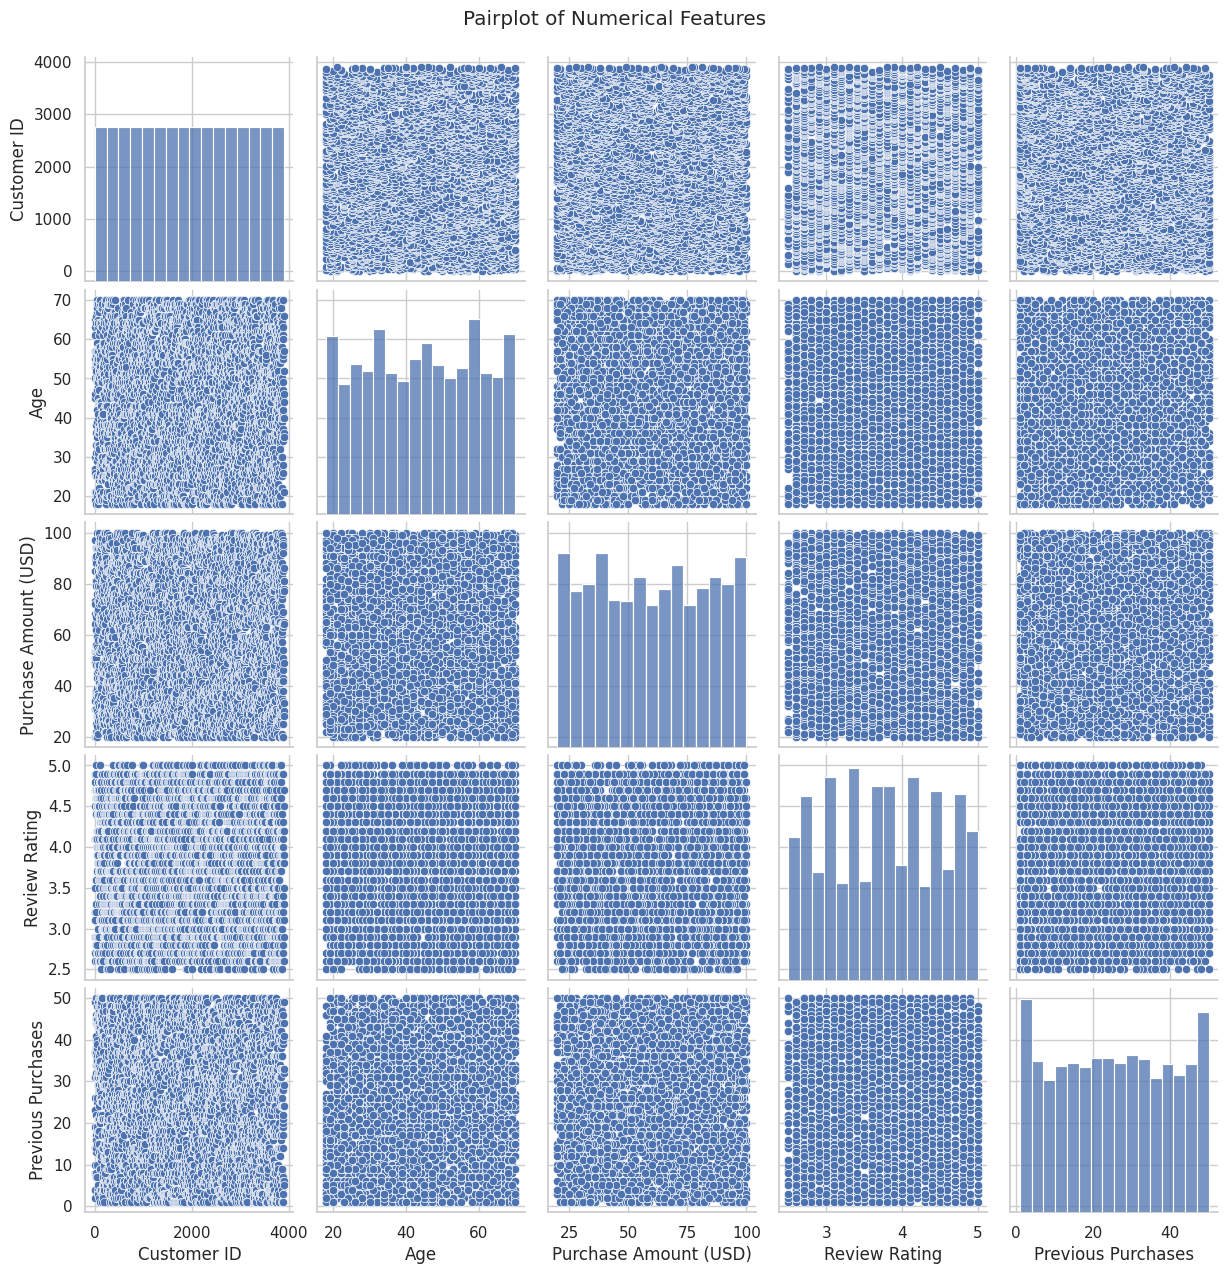

In [ ]:
# Pairplot for scatter plots between all numerical columns
print("\nPairplot (Scatter plots for numerical columns):")
sns.pairplot(df[numerical_cols])
plt.suptitle('Pairplot of Numerical Features', y=1.02) # Add a title to the pairplot
plt.show()

/tmp/ipykernel_830/2836849670.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Purchase Amount (USD)', data=df, palette='Set2')
/tmp/ipykernel_830/2836849670.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Purchase Amount (USD)', data=df, palette='Set2')
/tmp/ipykernel_830/2836849670.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Subscription Status', y='Review Rating', data=df, palette='Set2')


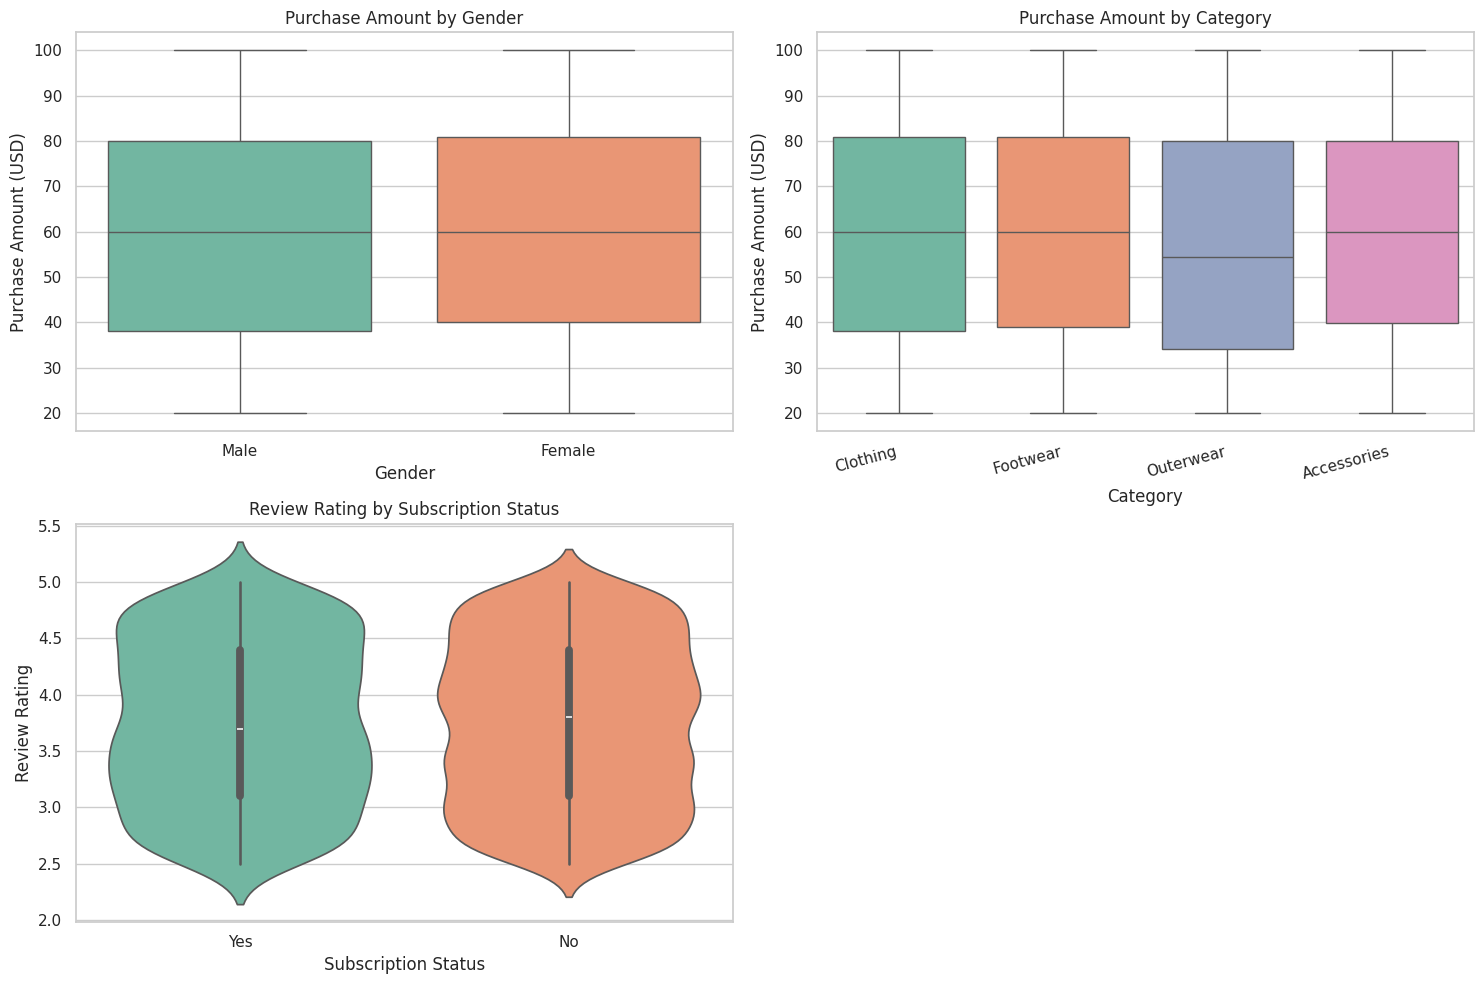

In [ ]:
plt.figure(figsize=(15, 10))

# 1. Purchase Amount (USD) by Gender
plt.subplot(2, 2, 1)
sns.boxplot(x='Gender', y='Purchase Amount (USD)', data=df, palette='Set2')
plt.title('Purchase Amount by Gender')

# 2. Purchase Amount (USD) by Category
plt.subplot(2, 2, 2)
sns.boxplot(x='Category', y='Purchase Amount (USD)', data=df, palette='Set2')
plt.title('Purchase Amount by Category')
plt.xticks(rotation=15, ha='right')

# 3. Review Rating by Subscription Status
plt.subplot(2, 2, 3)
sns.violinplot(x='Subscription Status', y='Review Rating', data=df, palette='Set2')
plt.title('Review Rating by Subscription Status')

plt.tight_layout()
plt.show()

In [ ]:
# Verified basic bivariate target relationships across main features.


C. Categorical vs. Categorical (e.g., Gender vs. Preferred Payment Method):

Cross-tabulation: Gender vs. Payment Method
Payment Method  Bank Transfer  Cash  Credit Card  Debit Card  PayPal  Venmo
Gender                                                                     
Female                    203   212          223         181     221    208
Male                      409   458          448         455     456    426


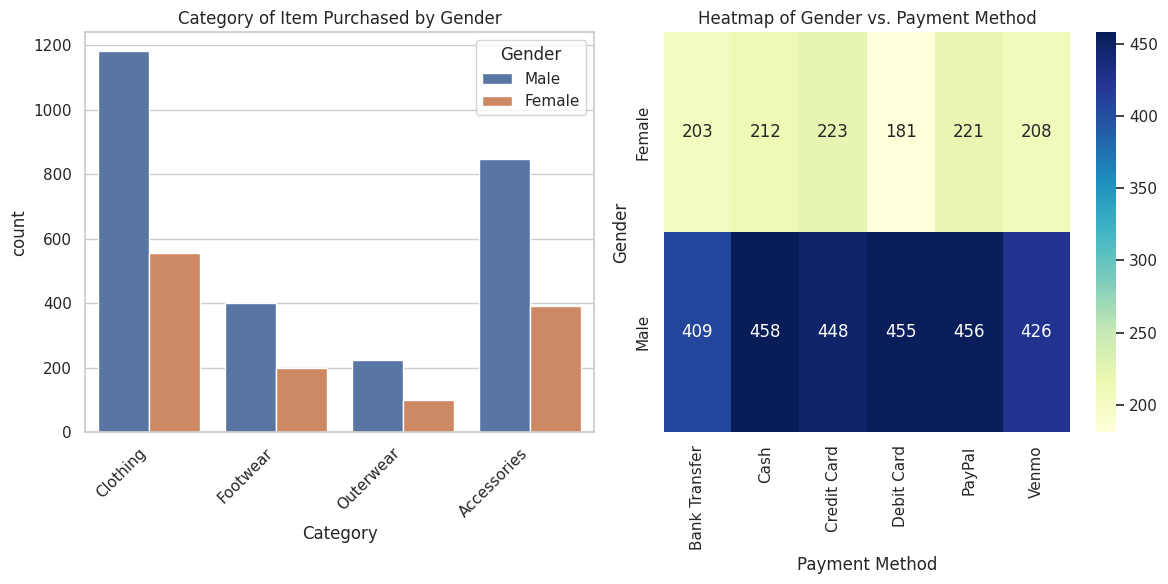

In [ ]:
# C. Categorical vs. Categorical: Count plots or Cross-tabulations (Heatmaps)
print("\nC. Categorical vs. Categorical (e.g., Gender vs. Preferred Payment Method):")
plt.figure(figsize=(12, 6))

# Example 1: Gender vs. Category of Item Purchased
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Category', hue='Gender')
plt.title('Category of Item Purchased by Gender')
plt.xticks(rotation=45, ha='right')

# Example 2: Cross-tabulation (contingency table) of Gender and Payment Method
print("\nCross-tabulation: Gender vs. Payment Method")
gender_payment_crosstab = pd.crosstab(df['Gender'], df['Payment Method'])
print(gender_payment_crosstab)

# Heatmap of the cross-tabulation
plt.subplot(1, 2, 2)
sns.heatmap(gender_payment_crosstab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap of Gender vs. Payment Method')
plt.tight_layout()
plt.show()

# 7. Multivariate Analysis


Purchase Amount by Category, broken down by Gender:


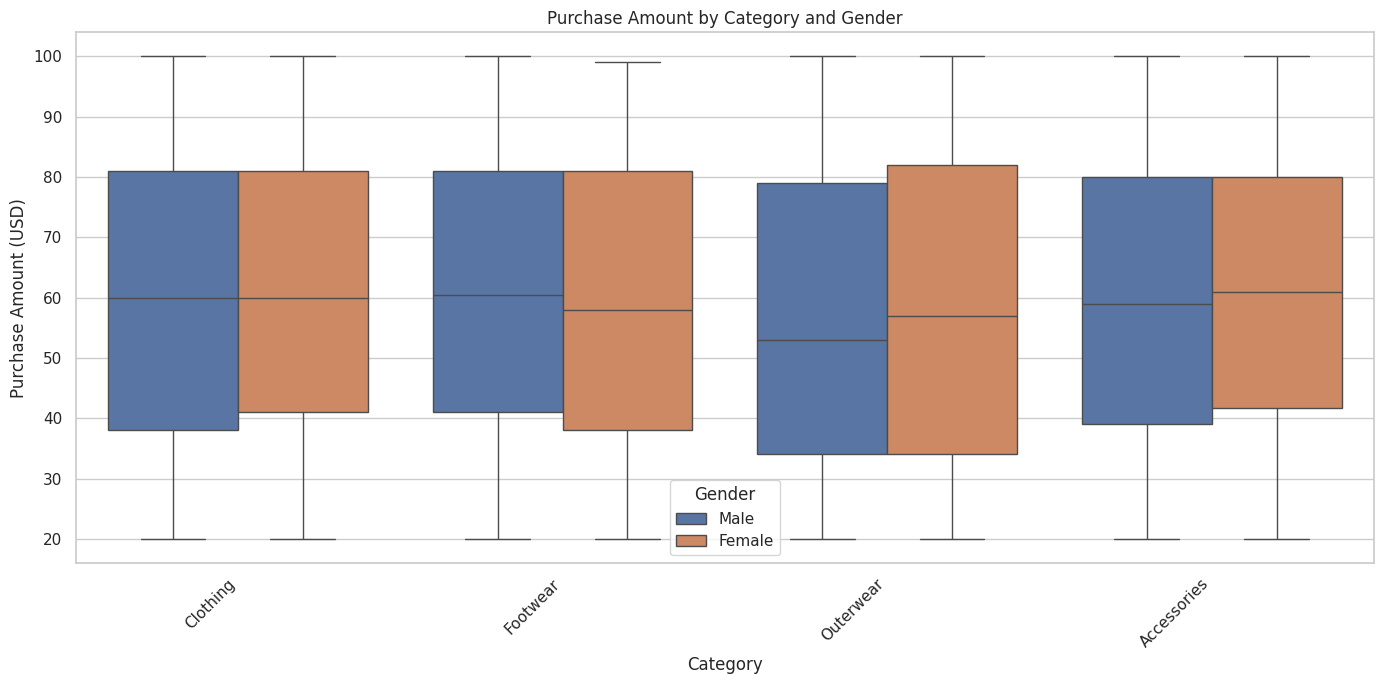


Age vs Purchase Amount, separated by Gender and Subscription Status:


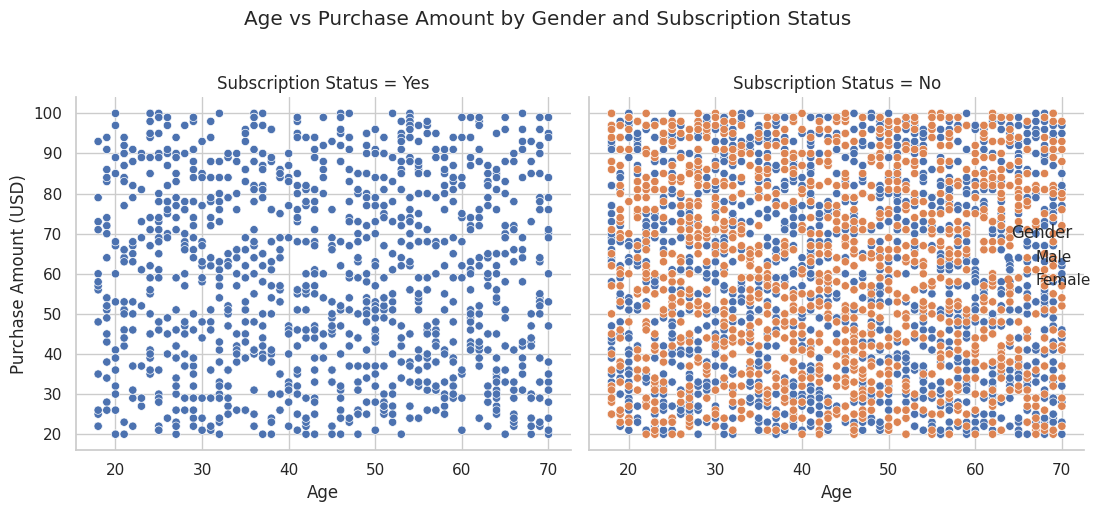

In [ ]:


# Example: Purchase Amount by Category, broken down by Gender
print("\nPurchase Amount by Category, broken down by Gender:")
plt.figure(figsize=(14, 7))
sns.boxplot(x='Category', y='Purchase Amount (USD)', hue='Gender', data=df)
plt.title('Purchase Amount by Category and Gender')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

# You can further explore relationships by using `col` or `row` parameters in `FacetGrid` or `relplot`
# For instance, a scatter plot of Age vs Purchase Amount, separated by Gender and Subscription Status
print("\nAge vs Purchase Amount, separated by Gender and Subscription Status:")
sns.relplot(x='Age', y='Purchase Amount (USD)', hue='Gender', col='Subscription Status', data=df, kind='scatter')
plt.suptitle('Age vs Purchase Amount by Gender and Subscription Status', y=1.02)
plt.tight_layout()
plt.show()

## 8. Predictive Churn Analysis

In [ ]:
# 1. Feature Engineering & Target Encoding
le = LabelEncoder()
df['Subscription_Status_Encoded'] = le.fit_transform(df['Subscription Status'])

features_df = df.drop(columns=['Customer ID', 'Subscription Status', 'Subscription_Status_Encoded'])
categorical_cols = features_df.select_dtypes(include=['object']).columns.tolist()
X = pd.get_dummies(features_df, columns=categorical_cols, drop_first=True)
y = df['Subscription_Status_Encoded']

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Model Training (Handling imbalance via class weights)
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# 4. Initial Results
y_pred = model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Test Accuracy: 0.8385


In [ ]:
# Verify feature dimensions after encoding
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (2730, 129)
X_test shape: (1170, 129)


In [ ]:
# Confirm model configuration
print(model)

RandomForestClassifier(class_weight='balanced', random_state=42)



Model Evaluation:
Accuracy: 0.8385

Classification Report:
              precision    recall  f1-score   support

          No       0.95      0.82      0.88       854
         Yes       0.65      0.89      0.75       316

    accuracy                           0.84      1170
   macro avg       0.80      0.86      0.81      1170
weighted avg       0.87      0.84      0.85      1170



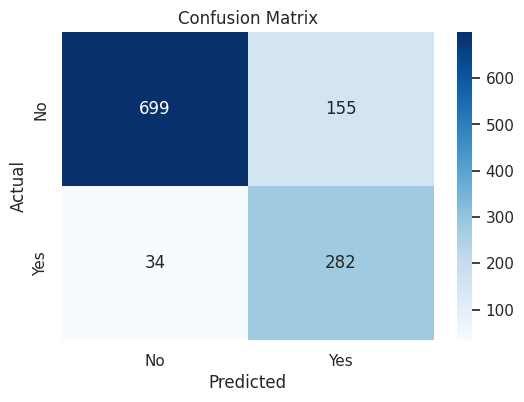

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Displaying the evaluation results obtained from the model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Plotting the confusion matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()